# 13RE - Detección de Anomalías: Experimentos Comparativos

En este notebook realizamos experimentos comparativos de detección de anomalías usando varios datasets (sintético, Iris, Wine, Digits, Diabetes).

**Objetivo**: inyectar outliers sintéticos, aplicar IsolationForest, LocalOutlierFactor y One-Class SVM, comparar métricas (precision/recall/f1) y visualizar los resultados en 2D (PCA, t-SNE, UMAP).

In [1]:
# Imports y comprobaciones iniciales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, load_iris, load_wine, load_digits, load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('UMAP no disponible (opcional).')
sns.set_style('whitegrid')
%matplotlib inline 
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## Plan de los experimentos
1. Cargar datasets base (sintético, Iris, Wine, Digits, Diabetes).
2. Inyectar outliers aleatorios en cada dataset (5-10% del total) para crear etiquetas `y_true` (-1 para outliers, 1 para inliers).
3. Ejecutar detectores: IsolationForest, LocalOutlierFactor y One-Class SVM.
4. Calcular métricas (precision, recall, f1) usando las etiquetas sintéticas.
5. Visualizar resultados en PCA/t-SNE/UMAP 2D por detector.

In [2]:
def inject_outliers(X, n_outliers=20, method='uniform', scale=3.0, random_state=42):
    """Inyecta outliers sintéticos al dataset X.
    method: 'uniform' o 'gaussian'
    scale: factor de amplitud/desviación para los outliers
    Retorna: X_aug (X + outliers), y_true (1=inlier, -1=outlier), X_out (outliers generados)
    """
    rng = np.random.RandomState(random_state)
    n_samples, n_features = X.shape
    if method == 'uniform':
        mins = X.min(axis=0) - scale # margen inferior
        maxs = X.max(axis=0) + scale # margen superior
        X_out = rng.uniform(low=mins, high=maxs, size=(n_outliers, n_features))
    elif method == 'gaussian':
        mu = X.mean(axis=0) # media de los datos
        sigma = X.std(axis=0) * scale # desviación ampliada
        X_out = rng.normal(loc=mu, scale=sigma, size=(n_outliers, n_features))
    else:
        raise ValueError('method debe ser "uniform" o "gaussian"')
    X_aug = np.vstack([X, X_out])
    y_true = np.ones(len(X_aug), dtype=int) # etiquetas verdaderas
    y_true[-n_outliers:] = -1 # etiquetas de outliers
    return X_aug, y_true, X_out

print('Función inject_outliers definida.')

Función inject_outliers definida.


In [3]:
# Obtener varios datasets para pruebas
def get_datasets():
    """Retorna una lista de (nombre, X) para varios datasets."""
    datasets = []
    # 1) Sintético (1 cluster + outliers)
    X_main, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.8, random_state=42)
    datasets.append(('Sintético', X_main))
    # 2) Iris (4D)
    iris = load_iris()
    datasets.append(('Iris', iris.data))
    # 3) Wine (13D)
    wine = load_wine()
    datasets.append(('Wine', wine.data))
    # 4) Digits (64D) - reducir muestras si es necesario para rapidez
    digits = load_digits()
    datasets.append(('Digits', digits.data))
    # 5) Diabetes (10D)
    diab = load_diabetes()
    datasets.append(('Diabetes', diab.data))
    return datasets

print('Función get_datasets definida.')

Función get_datasets definida.


In [4]:
# Crear detectores de anomalías
def make_detectors(contamination):
    """Crea un diccionario de detectores configurados con la contaminación especificada."""
    return {
        'IsolationForest': IsolationForest(contamination=contamination, random_state=42),
        'LocalOutlierFactor': LocalOutlierFactor(n_neighbors=20, contamination=contamination),
        'OneClassSVM': OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
    }

print('Función make_detectors definida.')

Función make_detectors definida.


In [5]:
# Ejecutar experimentos sobre un dataset
def run_on_dataset(name, X_raw, n_outliers=30, outlier_method='uniform'):
    """Ejecuta experimentos de detección de anomalías sobre un dataset.
    Retorna: X_aug (escalado + outliers), y_true, results (dict con métricas y predicciones por detector)
    """
    # Escalar
    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)
    # Inyectar outliers sintéticos
    X_aug, y_true, X_out = inject_outliers(X, n_outliers=n_outliers, method=outlier_method)
    contamination = float(n_outliers) / X_aug.shape[0]
    detectors = make_detectors(contamination)
    results = {}
    for dname, det in detectors.items():
        if dname == 'LocalOutlierFactor':
            # LOF: fit_predict sobre conjunto completo (no admite predict posterior)
            y_pred = det.fit_predict(X_aug)
        else:
            det.fit(X_aug)
            y_pred = det.predict(X_aug)
        # Métricas (pos_label=-1 para outliers)
        prec = precision_score(y_true, y_pred, pos_label=-1, zero_division=0)
        rec = recall_score(y_true, y_pred, pos_label=-1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=-1, zero_division=0)
        n_found = int(np.sum(y_pred == -1))
        results[dname] = {
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'n_found': n_found,
            'y_pred': y_pred
        }
    return X_aug, y_true, results

print('Función run_on_dataset definida.')

Función run_on_dataset definida.


In [6]:
## Ejecutar experimentos sobre todos los datasets

In [7]:
# Ejecutar experimentos
datasets = get_datasets()
summary_rows = []
all_outputs = {}

for name, X in datasets:
    print(f'Procesando: {name}')
    # Calcular n_outliers como ~5% del tamaño del dataset
    n_out = max(10, int(0.05 * len(X)))
    X_aug, y_true, results = run_on_dataset(name, X, n_outliers=n_out, outlier_method='uniform')
    all_outputs[name] = (X_aug, y_true, results)
    for dname, info in results.items():
        summary_rows.append({
            'dataset': name,
            'detector': dname,
            'precision': info['precision'],
            'recall': info['recall'],
            'f1': info['f1'],
            'n_found': info['n_found']
        })

summary_df = pd.DataFrame(summary_rows).sort_values(['dataset','detector'])
display(summary_df)
print('\nExperimentos completados. Usa plot_comparison_pca(dataset_name) para ver visualizaciones.')

Procesando: Sintético
Procesando: Iris
Procesando: Wine
Procesando: Digits
Procesando: Diabetes


,dataset,detector,precision,recall,f1,n_found
12,Diabetes,IsolationForest,1.000000,1.000000,1.000000,22
13,Diabetes,LocalOutlierFactor,1.000000,1.000000,1.000000,22
14,Diabetes,OneClassSVM,0.366667,0.500000,0.423077,30
9,Digits,IsolationForest,1.000000,1.000000,1.000000,89
10,Digits,LocalOutlierFactor,0.123596,0.123596,0.123596,89
11,Digits,OneClassSVM,0.777778,0.550562,0.644737,63
3,Iris,IsolationForest,1.000000,1.000000,1.000000,10
4,Iris,LocalOutlierFactor,0.900000,0.900000,0.900000,10
5,Iris,OneClassSVM,0.416667,0.500000,0.454545,12
0,Sintético,IsolationForest,0.800000,0.800000,0.800000,15



Experimentos completados. Usa plot_comparison_pca(dataset_name) para ver visualizaciones.


In [8]:
## Funciones de visualización

In [ ]:
# Visualizar resultados en PCA 2D
def plot_comparison_pca(dataset_name):
    """Visualiza resultados en PCA 2D para un dataset."""
    if dataset_name not in all_outputs:
        print('Dataset no procesado o nombre incorrecto')
        return
    X_aug, y_true, results = all_outputs[dataset_name]
    # PCA 2D
    pca = PCA(n_components=2, random_state=42)
    X2 = pca.fit_transform(X_aug)
    detectors = list(results.keys())
    n = len(detectors)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, dname in zip(axes, detectors):
        y_pred = results[dname]['y_pred']
        # Dibujar inliers predichos
        ax.scatter(X2[y_pred==1,0], X2[y_pred==1,1], c='white', edgecolors='k', s=25, label='Inlier (pred)', zorder=2)
        # Dibujar outliers predichos
        ax.scatter(X2[y_pred==-1,0], X2[y_pred==-1,1], c='red', s=25, label='Outlier (pred)', zorder=2)
        # Marcar outliers verdaderos con borde negro
        ax.scatter(X2[y_true==-1,0], X2[y_true==-1,1], facecolors='none', edgecolors='black', s=60, linewidths=1.2, label='Outlier (true)', zorder=3)
        ax.set_title(f'{dataset_name} - {dname}')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

print('Función plot_comparison_pca definida.')

Función plot_comparison_pca definida.


In [11]:
# Visualizar resultados en 2D usando PCA, t-SNE o UMAP
def plot_comparison_embedding(dataset_name, embedding='pca', tsne_perplexity=30, random_state=42, save_path=None):
    """Visualiza resultados en 2D usando PCA, t-SNE o UMAP.
    embedding: 'pca'|'tsne'|'umap'
    save_path: ruta opcional para guardar la figura (png).
    """
    if dataset_name not in all_outputs:
        print('Dataset no procesado o nombre incorrecto')
        return
    X_aug, y_true, results = all_outputs[dataset_name]
    # Calcular embedding reproducible
    if embedding == 'pca':
        emb = PCA(n_components=2, random_state=random_state).fit_transform(X_aug)
    elif embedding == 'tsne':
        # Pre-reducción con PCA si hay muchas dimensiones
        if X_aug.shape[1] > 50:
            X_pre = PCA(n_components=50, random_state=random_state).fit_transform(X_aug)
        else:
            X_pre = X_aug
        emb = TSNE(n_components=2, perplexity=tsne_perplexity, random_state=random_state).fit_transform(X_pre)
    elif embedding == 'umap':
        if not UMAP_AVAILABLE:
            print('UMAP no disponible en este entorno')
            return
        emb = umap.UMAP(n_components=2, random_state=random_state).fit_transform(X_aug)
    else:
        raise ValueError('embedding debe ser "pca", "tsne" o "umap"')

    detectors = list(results.keys())
    n = len(detectors)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, dname in zip(axes, detectors):
        y_pred = results[dname]['y_pred']
        ax.scatter(emb[y_pred==1,0], emb[y_pred==1,1], c='white', edgecolors='k', s=25, label='Inlier (pred)', zorder=2)
        ax.scatter(emb[y_pred==-1,0], emb[y_pred==-1,1], c='red', s=25, label='Outlier (pred)', zorder=2)
        # Outliers verdaderos
        ax.scatter(emb[y_true==-1,0], emb[y_true==-1,1], facecolors='none', edgecolors='black', s=60, linewidths=1.2, label='Outlier (true)', zorder=3)
        ax.set_title(f'{dataset_name} - {dname} ({embedding.upper()})')
        ax.set_xlabel('Dim 1')
        ax.set_ylabel('Dim 2')
        ax.legend(loc='upper right')
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Figura guardada en: {save_path}')
    plt.show()

print('Función plot_comparison_embedding definida.')

Función plot_comparison_embedding definida.


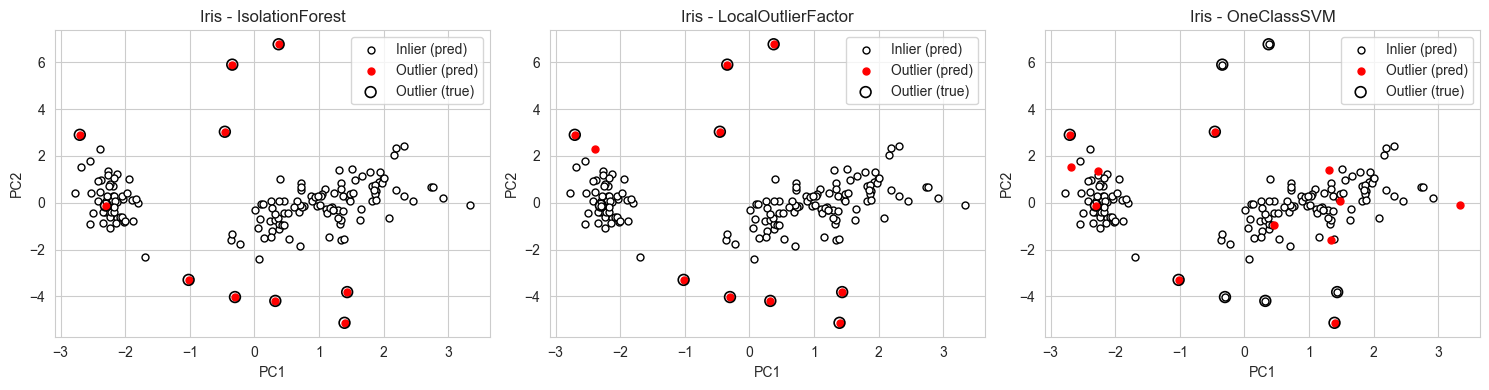

In [12]:
## Ejemplos de uso

# Visualizar con PCA:
plot_comparison_pca('Iris')

# Visualizar con t-SNE:
# plot_comparison_embedding('Wine', embedding='tsne', tsne_perplexity=30, random_state=42)

# Visualizar con UMAP (si está instalado) y guardar:
# plot_comparison_embedding('Digits', embedding='umap', random_state=42, save_path='imagenes/digits_umap.png')

# Exportar tabla de métricas a CSV:
# summary_df.to_csv('resultados/deteccion_anomalias_summary.csv', index=False)

In [13]:
## Pruebas: Visualizar dataset Sintético

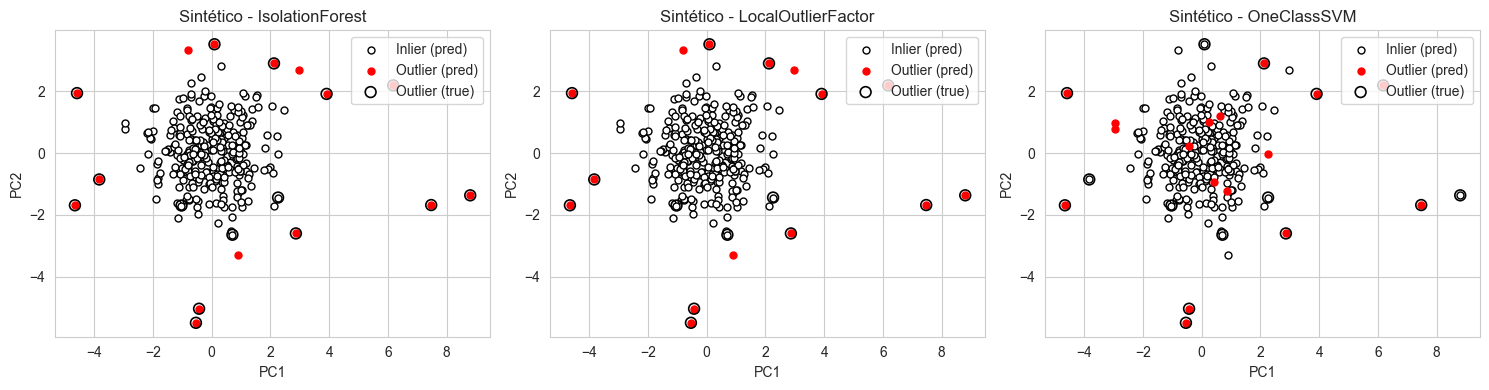

In [14]:
plot_comparison_pca('Sintético')

In [ ]:
## Pruebas: Visualizar dataset Iris

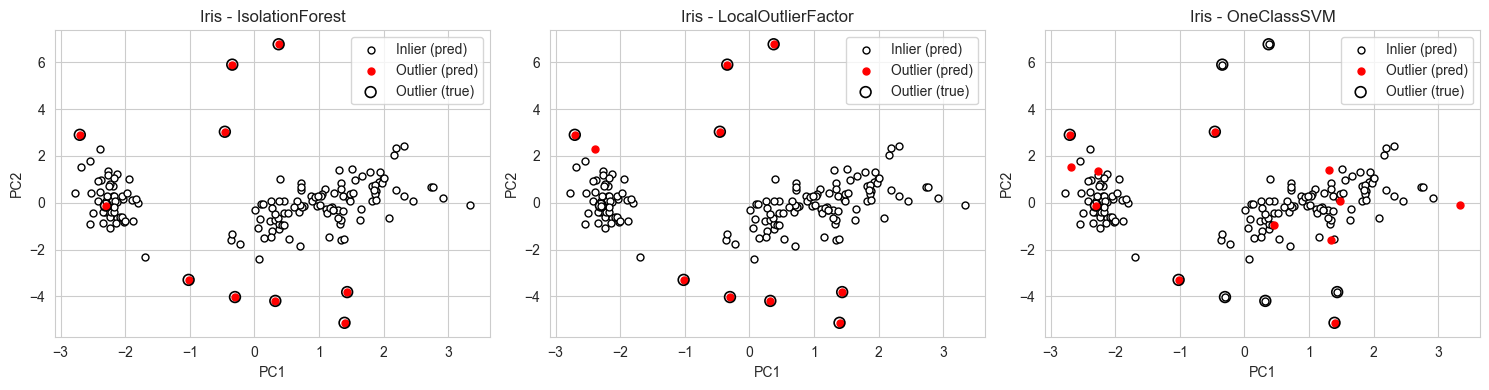

In [15]:
plot_comparison_pca('Iris')

In [ ]:
## Pruebas: Visualizar dataset Wine con t-SNE

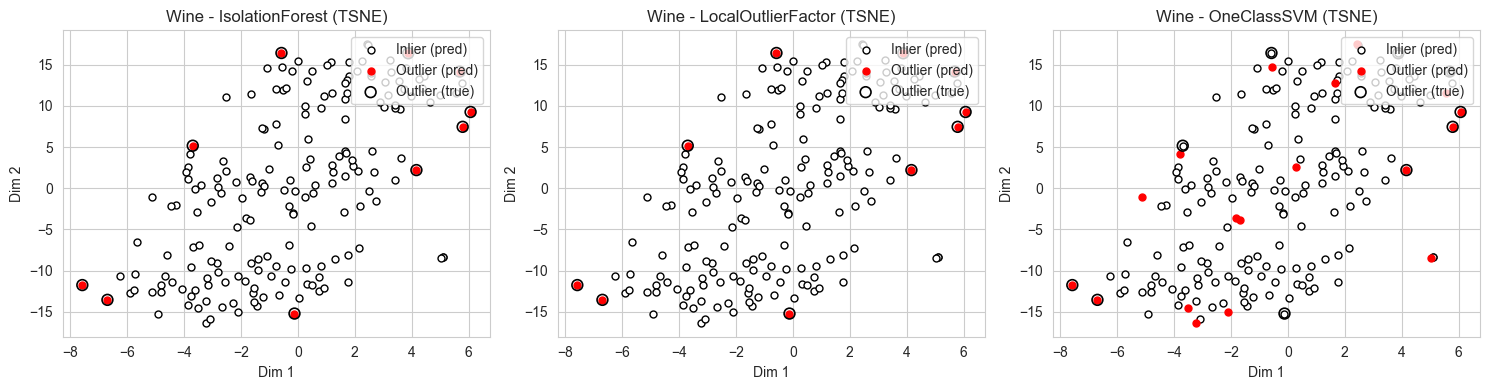

In [16]:
plot_comparison_embedding('Wine', embedding='tsne', tsne_perplexity=30, random_state=42)

In [ ]:
## Pruebas: Visualizar dataset Digits con PCA

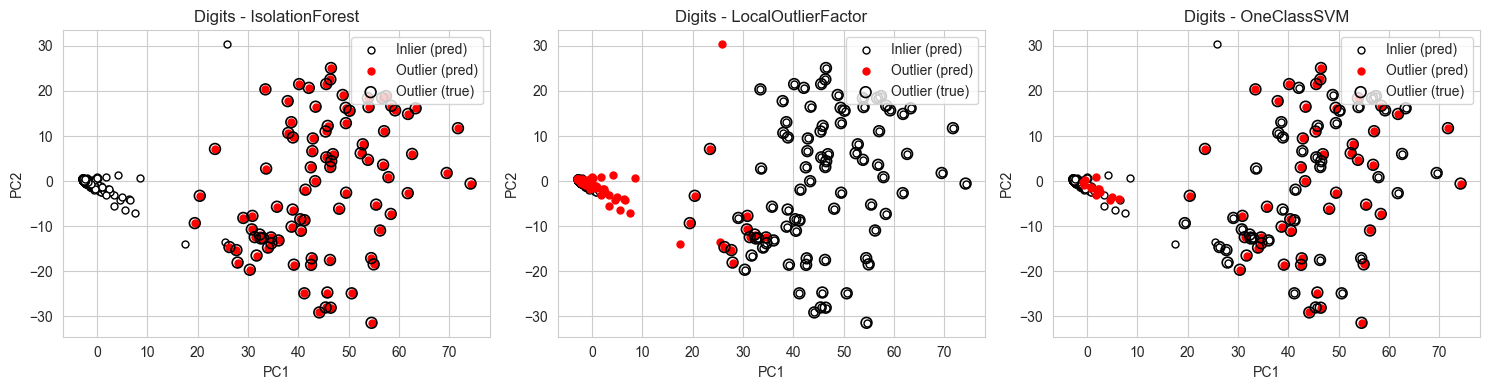

In [17]:
plot_comparison_pca('Digits')

In [ ]:
## Pruebas: Visualizar dataset Diabetes con PCA

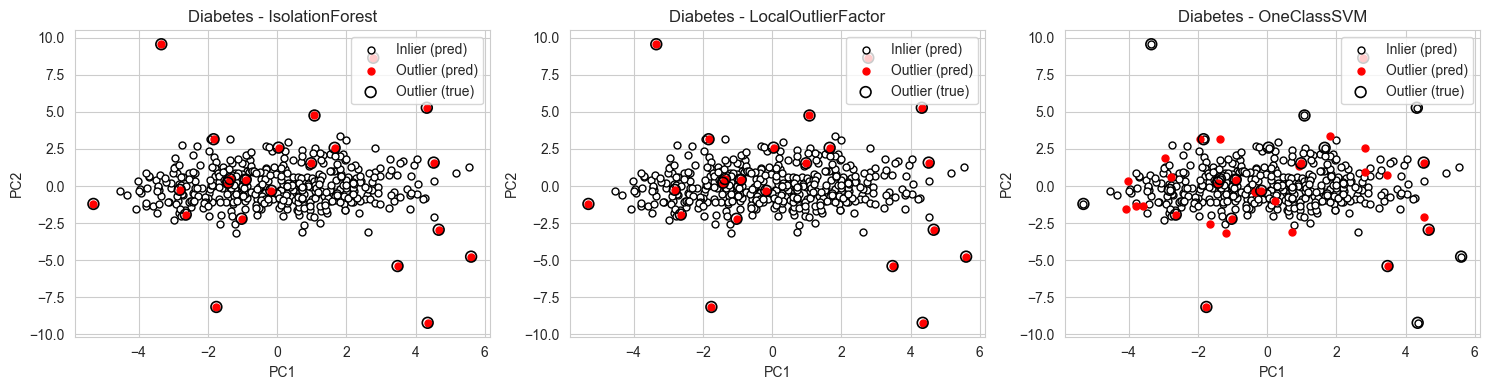

In [18]:
plot_comparison_pca('Diabetes')

## Análisis de resultados

Revisa la tabla `summary_df` para comparar:
- **Precision**: De los puntos marcados como outliers, ¿cuántos realmente lo son?
- **Recall**: De los outliers verdaderos, ¿cuántos fueron detectados?
- **F1**: Media armónica de precision y recall.

En general:
- **IsolationForest**: rápido, bueno en alta dimensión, pero puede tener falsos positivos en datasets con densidades variables.
- **LocalOutlierFactor**: sensible a variaciones de densidad local, más lento, excelente para outliers contextuales.
- **OneClassSVM**: buena frontera teórica, sensible a parámetros (nu, gamma), puede requerir ajuste.

In [19]:
## Comparación visual de métricas por dataset

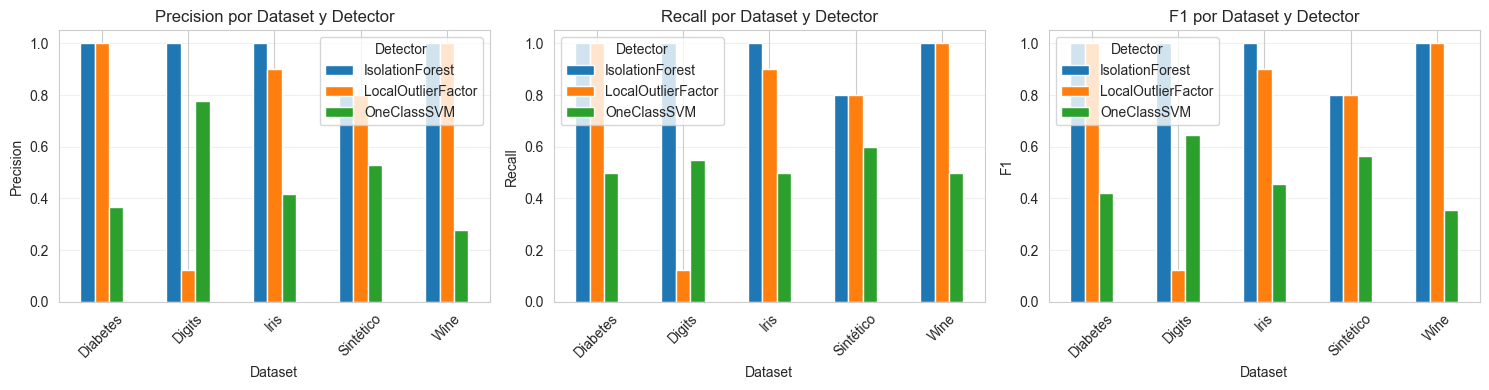

In [20]:
# Visualizar métricas como gráficos de barras
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, metric in enumerate(['precision', 'recall', 'f1']):
    pivot = summary_df.pivot(index='dataset', columns='detector', values=metric)
    pivot.plot(kind='bar', ax=axes[i], rot=45)
    axes[i].set_title(f'{metric.capitalize()} por Dataset y Detector')
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_xlabel('Dataset')
    axes[i].legend(title='Detector', loc='best')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusiones y recomendaciones

**Observaciones clave:**

1. **IsolationForest** suele tener buen equilibrio entre precision y recall, especialmente en datasets de alta dimensionalidad como Digits.

2. **LocalOutlierFactor** puede ser muy efectivo en datasets con estructuras de densidad complejas, pero requiere ajustar `n_neighbors`.

3. **OneClassSVM** puede ser más sensible a los parámetros `nu` y `gamma`. Es efectivo cuando se conoce bien la proporción esperada de outliers.

**Recomendaciones:**

- Para datasets grandes y de alta dimensión: **IsolationForest**
- Para datos con variaciones de densidad local: **LocalOutlierFactor**
- Para fronteras de decisión complejas y no lineales: **OneClassSVM**
- Siempre validar con métricas apropiadas y ajustar hiperparámetros según el contexto específico del problema.